<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_1_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST (simple black and white digits)

Step 1: Setting Up the Environment


In [ ]:
pip install numpy matplotlib tensorflow

Step 2: Importing Libraries

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

Step 3: Loading and Preprocessing the MNIST Dataset

In [ ]:
# Load the dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the data to include the channel dimension
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



Step 4: Building the Autoencoder Model

In [ ]:
# Define the input shape for the autoencoder
input_shape = (28, 28, 1)

# Define the encoder part of the autoencoder
input_img = Input(shape=input_shape)
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Define the decoder part of the autoencoder
decoded = Dense(784, activation='sigmoid')(encoded)
decoded = Reshape((28, 28, 1))(decoded)

# Define the complete autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

# Print the summary of the autoencoder model
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

Step 5: Training the Autoencoder Model

In [ ]:
# Train the autoencoder
autoencoder.fit(x_train, x_train,
   epochs = 50,		# Number of epochs to train
   batch_size=256,	# Batch size for training
   shuffle=True,
   validation_data = (x_test, x_test)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3452 - val_loss: 0.1614
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1520 - val_loss: 0.1252
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1219 - val_loss: 0.1079
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1062 - val_loss: 0.0975
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0965 - val_loss: 0.0901
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0896 - val_loss: 0.0845
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0845 - val_loss: 0.0809
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0812 - val_loss: 0.0786
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0789 - val_loss: 0.0771
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0776 - val_loss: 0.0762
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0766 - val_loss: 0.0753
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 


Step 6: Visualizing Original and Reconstructed Data

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


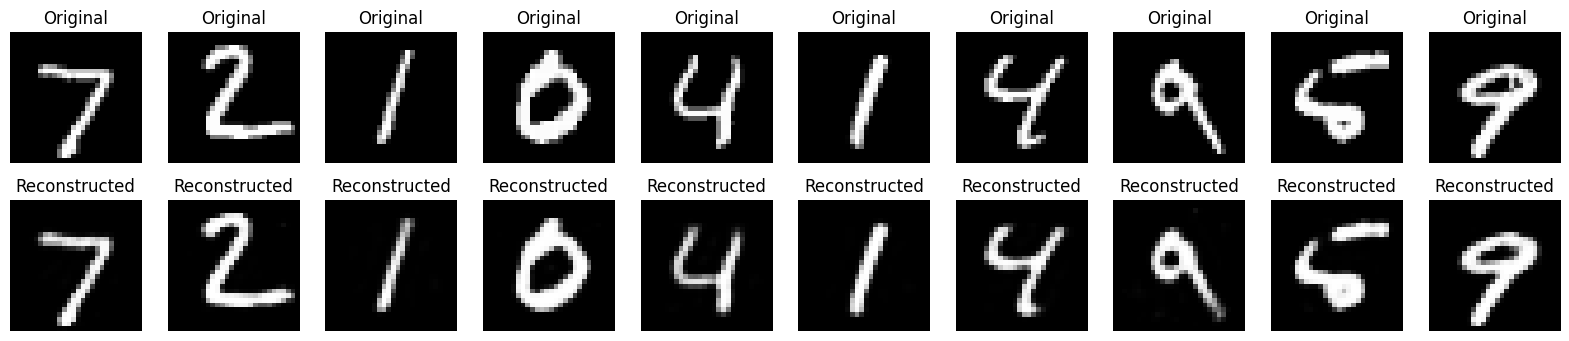

In [ ]:
# Predict the reconstructed images from the test set
decoded_imgs = autoencoder.predict(x_test)

# Number of digits to display
n = 10

# Create a figure with a specified size
plt.figure(figsize=(20, 4))

# Loop through the first n test images

for i in range(n):

   # Display the original image
   ax = plt.subplot(2, n, i + 1)  # Create a subplot for the original image

   # Reshape and plot the original image
   plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
   plt.title("Original")  # Set the title of the plot
   plt.axis('off')

   # Display the reconstructed image
   ax = plt.subplot(2, n, i + 1 + n)
   plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
   plt.title("Reconstructed")
   plt.axis('off')

# Show the figure
plt.show()

# CIFAR-10 (complex color images like cars, birds, and frogs)

Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10 # Changed from mnist to cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

Load the CIFAR-10 dataset

In [ ]:
# CIFAR-10 contains 60,000 32x32 color images in 10 classes
(x_train, _), (x_test, _) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Normalize the data

In [ ]:
# Convert pixel values from 0-255 to 0.0-1.0 for better training speed
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

Define the input shape

In [ ]:
# 32x32 pixels, 3 color channels (Red, Green, Blue)
input_shape = (32, 32, 3)

Building the Model

In [ ]:
# --- ENCODER ---
input_img = Input(shape=input_shape)
x = Flatten()(input_img) # Flatten 32x32x3 into a single list of 3072 numbers

# We compress 3072 numbers down to 512 (the "Summary")
encoded = Dense(512, activation='relu')(x)

# --- DECODER ---
# We try to expand the 512 numbers back into the original 3072
decoded = Dense(3072, activation='sigmoid')(encoded)

# Fold the 3072 numbers back into a 32x32x3 color image square
decoded = Reshape((32, 32, 3))(decoded)

# --- FULL MODEL ---
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # Using Mean Squared Error for colors

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3072)           │     1,575,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,149,312 (12.01 MB)

 Trainable params: 3,149,312 (12.01 MB)

 Non-trainable params: 0 (0.00 B)

Training and Testing

In [ ]:
# 4. Train the model
# We use x_train as both the input and the target (teaching it to copy itself)
autoencoder.fit(x_train, x_train,
                epochs=30, # CIFAR is harder, might need more time
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# 5. Test the model
decoded_imgs = autoencoder.predict(x_test)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - loss: 0.0420 - val_loss: 0.0221
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - loss: 0.0211 - val_loss: 0.0179
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - loss: 0.0170 - val_loss: 0.0144
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - loss: 0.0145 - val_loss: 0.0125
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - loss: 0.0125 - val_loss: 0.0112
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.0116 - val_loss: 0.0104
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - loss: 0.0111 - val_loss: 0.0100
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - loss: 0.0101 - val_loss: 0.0093
Epoch 9/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - loss: 0.0094 - val_loss: 0.0094
Epoch 10/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - loss: 0.0093 - val_loss: 0.0117
Epoch 11/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - loss: 0.0094 - val_loss: 0.0085
Epoch 12/30
196/196

Plotting the results

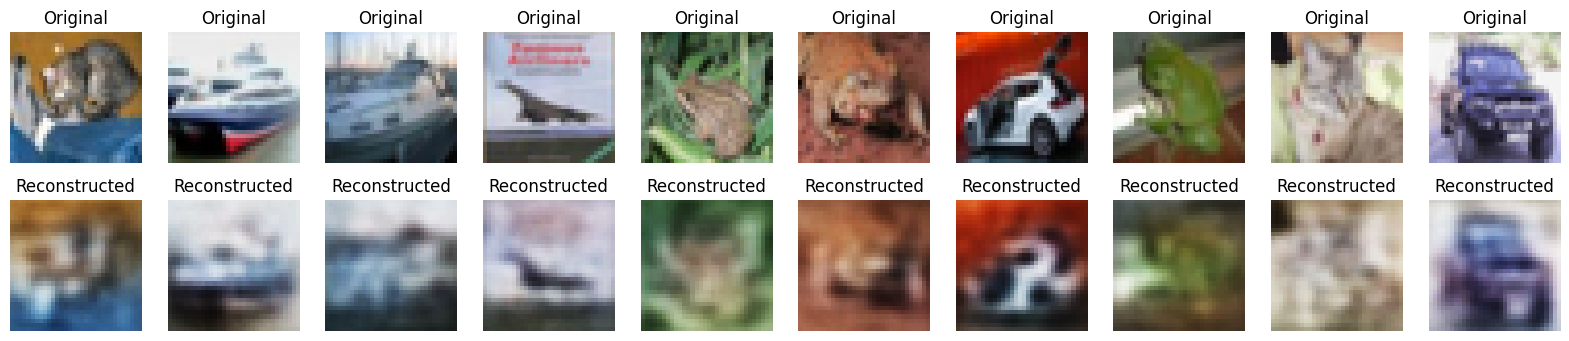

In [ ]:
n = 10 # Number of images to show
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i]) # No need for cmap='gray' since it's color!
    plt.title("Original")
    plt.axis('off')

    # Display Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()